In [ ]:

"""
Meta KAPI-RBF PINN (meta-SPINN) for 2D Poisson with Gaussian source:
    -Δu = f(x,y; x0, y0, nu)  on [0,1]^2,  u = 0 on boundary.
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import numpy as np
import matplotlib.pyplot as plt
import os
import random

from matplotlib.patches import Circle  # not essential but kept

# Device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Directory to save figures and model
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

MODEL_PATH = "meta_poisson_model.pt"  # where we'll save the trained model

# Reproducibility
SEED = 1234

# Python & NumPy
random.seed(SEED)
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# For (more) deterministic behavior on GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed set to:", SEED)


Using device: cpu
Random seed set to: 1234


In [ ]:
# -------------------------------------------------------------------
# 2D Gaussian source term for Poisson:  f(x,y) = (1/(2πν^2)) exp(...)
# -------------------------------------------------------------------
def gaussian_source(x, y, x0, y0, nu):
    """
    x, y: (N,) tensors
    x0, y0, nu: scalars (0D tensors or floats)
    returns f(x,y) shape (N,)
    """
    r2 = (x - x0)**2 + (y - y0)**2
    return (1.0 / (2.0 * torch.pi * nu**2)) * torch.exp(-r2 / (2.0 * nu**2))


# -------------------------------------------------------------------
# KAPI-RBF PINN model (meta-conditioned on PDE parameters)
# -------------------------------------------------------------------
class KAPIRBF_PINN(nn.Module):
    def __init__(self, M=128, hidden_meta=64):
        super().__init__()
        self.M = M

        # Meta-network: p_norm -> [g_logits, mu_x_raw, mu_y_raw, log_sigma_raw]
        self.meta = nn.Sequential(
            nn.Linear(3, hidden_meta),
            nn.Tanh(),
            nn.Linear(hidden_meta, hidden_meta),
            nn.Tanh(),
            nn.Linear(hidden_meta, 4 * M)
        )

        # Global coefficients c_j (shared across all PDE params), small random init
        self.c = nn.Parameter(1e-2 * torch.randn(M))

    def _forward_raw(self, p, xy):
        """
        Raw RBF expansion (no BC factor).
        p: (1,3) tensor, PDE parameter [x0, y0, nu]
        xy: (N,2) spatial points in [0,1]^2
        Returns:
            u_raw: (N,)
            aux: (g, mu_x, mu_y, sigma)
        """
        assert p.shape[0] == 1, "This implementation assumes a single p per call."

        # Normalize p = (x0, y0, nu)
        p_mean = p.new_tensor([0.5, 0.5, 0.075])
        p_std  = p.new_tensor([0.1, 0.1, 0.025])
        p_norm = (p - p_mean) / p_std

        # meta-mapping
        meta_out = self.meta(p_norm)              # (1, 4*M)
        meta_out = meta_out.view(1, 4, self.M)

        g_logits   = meta_out[:, 0, :]       # (1, M)
        mu_raw_x   = meta_out[:, 1, :]       # (1, M)
        mu_raw_y   = meta_out[:, 2, :]       # (1, M)
        log_sigraw = meta_out[:, 3, :]       # (1, M)

        # Gates in (0,1)
        g = torch.sigmoid(g_logits).view(self.M)   # (M,)

        # Centers in (0,1)
        mu_x = torch.sigmoid(mu_raw_x).view(self.M)
        mu_y = torch.sigmoid(mu_raw_y).view(self.M)

        # Widths > 0
        sigma = torch.nn.functional.softplus(log_sigraw).view(self.M) + 5e-4

        # Build RBF features Phi(x,y) -> (N,M)
        x = xy[:, 0:1]  # (N,1)
        y = xy[:, 1:2]  # (N,1)

        x_diff = x - mu_x.view(1, self.M)
        y_diff = y - mu_y.view(1, self.M)
        r2 = (x_diff**2 + y_diff**2) / (sigma.view(1, self.M)**2)
        Phi = torch.exp(-r2)  # (N,M)

        coeff = g * self.c    # (M,)
        u_raw = Phi @ coeff   # (N,)

        return u_raw, (g, mu_x, mu_y, sigma)

    def forward(self, p, xy):
        """
        Full forward with BC-satisfying trial ansatz:
            u(x,y;p) = x(1-x)y(1-y) * u_raw(x,y;p)
        """
        u_raw, aux = self._forward_raw(p, xy)
        x, y = xy[:, 0:1], xy[:, 1:2]
        bc_factor = x * (1.0 - x) * y * (1.0 - y)   # (N,1)
        u = u_raw * bc_factor.view(-1)             # (N,)
        return u, aux


In [ ]:
# -------------------------------------------------------------------
# p-dependent collocation and boundary points on [0,1]^2
# -------------------------------------------------------------------
def sample_collocation_points_p_dependent(
    N_int,
    N_bc,
    p,
    alpha=None,
    sigma_factor=3.0,
    device=device
):
    """
    N_int : number of interior collocation points
    N_bc  : number of boundary collocation points
    p     : (1,3) tensor = [x0, y0, nu] on 'device'
    """
    x0, y0, nu = p[0]  # each is a scalar tensor on 'device'

    # Choose alpha based on nu: more localized sampling for smaller nu
    if alpha is None:
        if nu.item() < 0.06:
            alpha = 0.9
        else:
            alpha = 0.7

    # Interior points
    N_loc = int(alpha * N_int)
    N_uni = N_int - N_loc

    if N_loc > 0:
        loc_x = x0 + sigma_factor * nu * torch.randn(N_loc, 1, device=device)
        loc_y = y0 + sigma_factor * nu * torch.randn(N_loc, 1, device=device)
        loc_x = loc_x.clamp(0.0, 1.0)
        loc_y = loc_y.clamp(0.0, 1.0)
        xy_loc = torch.cat([loc_x, loc_y], dim=1)
    else:
        xy_loc = torch.empty(0, 2, device=device)

    if N_uni > 0:
        uni_x = torch.rand(N_uni, 1, device=device)
        uni_y = torch.rand(N_uni, 1, device=device)
        xy_uni = torch.cat([uni_x, uni_y], dim=1)
    else:
        xy_uni = torch.empty(0, 2, device=device)

    xy_int = torch.cat([xy_loc, xy_uni], dim=0)  # (N_int, 2)

    # Boundary points
    if N_bc > 0:
        N_side = N_bc // 4
        t = torch.rand(N_side, 1, device=device)

        xb = torch.cat([
            torch.zeros(N_side, 1, device=device),
            torch.ones(N_side, 1, device=device),
            t,
            t
        ], dim=0)

        yb = torch.cat([
            t,
            t,
            torch.zeros(N_side, 1, device=device),
            torch.ones(N_side, 1, device=device)
        ], dim=0)

        xy_bc = torch.cat([xb, yb], dim=1)
    else:
        xy_bc = torch.empty(0, 2, device=device)

    return xy_int, xy_bc


# -------------------------------------------------------------------
# Compute PDE residual for Poisson: -Δu - f(x,y;p)
# -------------------------------------------------------------------
def poisson_residual(model, p, xy_int):
    xy_int.requires_grad_(True)
    u, _ = model(p, xy_int)

    grads = torch.autograd.grad(
        u, xy_int,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    u_x = grads[:, 0]
    u_y = grads[:, 1]

    grads2_x = torch.autograd.grad(
        u_x, xy_int,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]
    grads2_y = torch.autograd.grad(
        u_y, xy_int,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0]

    u_xx = grads2_x[:, 0]
    u_yy = grads2_y[:, 1]
    laplace_u = u_xx + u_yy

    x = xy_int[:, 0]
    y = xy_int[:, 1]
    x0, y0, nu = p[0, 0], p[0, 1], p[0, 2]
    f_val = gaussian_source(x, y, x0, y0, nu)

    residual = -laplace_u - f_val
    return residual


# -------------------------------------------------------------------
# Sample PDE parameters p = (x0, y0, nu)
# -------------------------------------------------------------------
x0_min, x0_max = 0.4, 0.6
y0_min, y0_max = 0.4, 0.6
nu_min, nu_max = 0.05, 0.1   # global Gaussian width range

def sample_pde_param(nu_min_curr=None, nu_max_curr=None):
    if nu_min_curr is None:
        nu_min_curr = nu_min
    if nu_max_curr is None:
        nu_max_curr = nu_max

    x0 = x0_min + (x0_max - x0_min) * torch.rand(1)
    y0 = y0_min + (y0_max - y0_min) * torch.rand(1)

    # log-uniform in nu
    u = torch.rand(1)
    nu_min_t = torch.tensor(nu_min_curr)
    nu_max_t = torch.tensor(nu_max_curr)
    nu = 10.0**(torch.log10(nu_min_t) +
                (torch.log10(nu_max_t) - torch.log10(nu_min_t)) * u)

    p = torch.stack([x0, y0, nu], dim=-1)  # (1,3)
    return p.to(device)


# -------------------------------------------------------------------
# Meta-training loop (returns best model + training history)
# -------------------------------------------------------------------
def train_meta_poisson(
    n_int=2048,
    n_bc=256,
    epochs=2000,   # you can reduce for testing
    lr=1e-3,
    M=128,
    tasks_per_batch=4
):
    model = KAPIRBF_PINN(M=M, hidden_meta=64).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = StepLR(optimizer, step_size=1000, gamma=0.5)

    # For saving the best model (based on training loss)
    best_loss = float("inf")
    best_state = None

    # ✅ History dictionary for plotting
    history = {
        "epoch": [],
        "total_loss": [],
        "pde_loss": [],
        "bc_loss": [],
        "lr": [],
    }

    for ep in range(1, epochs + 1):
        optimizer.zero_grad()

        total_loss = 0.0
        total_pde  = 0.0
        total_bc   = 0.0

        # ν-curriculum
        if ep <= epochs // 2:
            nu_min_curr, nu_max_curr = 0.08, nu_max
        else:
            nu_min_curr, nu_max_curr = nu_min, nu_max

        for _ in range(tasks_per_batch):
            p = sample_pde_param(nu_min_curr, nu_max_curr)

            xy_int, xy_bc = sample_collocation_points_p_dependent(
                n_int, n_bc, p,
                alpha=None,
                sigma_factor=3.0,
                device=device
            )

            # PDE loss
            res_int = poisson_residual(model, p, xy_int)
            loss_pde = torch.mean(res_int**2)

            # BC monitoring (u should already satisfy BC)
            if xy_bc.shape[0] > 0:
                u_bc, (g_bc, _, _, _) = model(p, xy_bc)
                loss_bc = torch.mean(u_bc**2)
            else:
                dummy_xy = torch.zeros(1, 2, device=device)
                _, (g_bc, _, _, _) = model(p, dummy_xy)
                loss_bc = torch.tensor(0.0, device=device)

            # Optional sparsity penalty
            loss_sparse = 1e-5 * torch.mean(torch.abs(g_bc))

            loss_task = loss_pde + loss_sparse

            total_loss += loss_task
            total_pde  += loss_pde
            total_bc   += loss_bc

        # Average over PDE tasks
        total_loss = total_loss / tasks_per_batch
        total_pde  = total_pde  / tasks_per_batch
        total_bc   = total_bc   / tasks_per_batch

        # Backpropagation
        total_loss.backward()
        optimizer.step()
        scheduler.step()

        # Current learning rate (StepLR may change it)
        current_lr = scheduler.get_last_lr()[0]

        # ✅ Log into history (convert tensors to floats with .item())
        history["epoch"].append(ep)
        history["total_loss"].append(total_loss.item())
        history["pde_loss"].append(total_pde.item())
        history["bc_loss"].append(total_bc.item())
        history["lr"].append(current_lr)

        # ✅ Track best model
        if total_loss.item() < best_loss:
            best_loss = total_loss.item()
            best_state = model.state_dict()

        # Print occasionally
        if ep % 200 == 0:
            print(
                f"Epoch {ep:5d} | Loss: {total_loss.item():.3e} "
                f"(PDE: {total_pde.item():.3e}, BC(mon.): {total_bc.item():.3e}, "
                f"lr={current_lr:.1e})"
            )

    print(f"\nBest training loss = {best_loss:.3e}")

    # Load best weights before returning
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


In [ ]:
# -------------------------------------------------------------------
# FDM "exact" solver for a *fixed* Poisson instance
# -------------------------------------------------------------------
def poisson_exact_fdm(N=60, x0=0.5, y0=0.5, nu=0.05):
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    dx = x[1] - x[0]
    X, Y = np.meshgrid(x, y, indexing='ij')

    r2 = (X - x0)**2 + (Y - y0)**2
    f = (1.0/(2.0*np.pi*nu**2)) * np.exp(-r2/(2.0*nu**2))

    Nint = N - 2
    f_inner = f[1:-1, 1:-1].reshape(-1)

    e = np.ones(Nint)
    D2 = (np.diag(-2*e) + np.diag(e[:-1], 1) + np.diag(e[:-1], -1)) / dx**2
    I = np.eye(Nint)

    L = np.kron(I, D2) + np.kron(D2, I)

    rhs = -f_inner
    u_inner = np.linalg.solve(L, rhs)

    u = np.zeros((N, N))
    u[1:-1, 1:-1] = u_inner.reshape(Nint, Nint)
    return x, y, u


# Test cases definition (reuse in multiple cells)
test_cases = [
    ("center_in_range",      0.50, 0.50, 0.07),
    ("off_center_in_range",  0.45, 0.55, 0.09),
    ("shifted_out_of_range", 0.30, 0.30, 0.06),
    ("narrow_out_of_range",  0.50, 0.50, 0.03),
]


# -------------------------------------------------------------------
# Plot solutions and error for a given model
# -------------------------------------------------------------------
def evaluate_and_plot_solutions(model, N=60):
    num_tests = len(test_cases)

    fig, axs = plt.subplots(
        num_tests, 3,
        figsize=(15, 4 * num_tests),
        constrained_layout=True
    )

    if num_tests == 1:
        axs = np.array([axs])

    rel_errors = []
    model.eval()

    for i, (name, x0_test, y0_test, nu_test) in enumerate(test_cases):
        print(f"\n=== Test case {i+1}/{num_tests}: {name} ===")
        print(f"  (x0, y0, nu) = ({x0_test:.3f}, {y0_test:.3f}, {nu_test:.3f})")

        xg, yg, u_exact = poisson_exact_fdm(
            N=N, x0=x0_test, y0=y0_test, nu=nu_test
        )

        Xg, Yg = np.meshgrid(xg, yg, indexing='ij')
        xy_grid = np.stack([Xg.reshape(-1), Yg.reshape(-1)], axis=1)
        xy_grid_t = torch.tensor(xy_grid, dtype=torch.float32, device=device)

        p_test = torch.tensor(
            [[x0_test, y0_test, nu_test]],
            dtype=torch.float32,
            device=device
        )

        with torch.no_grad():
            u_pred_flat, _ = model(p_test, xy_grid_t)
        u_meta = u_pred_flat.cpu().numpy().reshape(N, N)

        err = u_meta - u_exact
        rel_L2 = np.linalg.norm(err.ravel()) / np.linalg.norm(u_exact.ravel())
        print(f"  Relative L2 error = {rel_L2:.3e}")
        rel_errors.append((name, rel_L2))

        ax0, ax1, ax2 = axs[i, 0], axs[i, 1], axs[i, 2]

        im0 = ax0.imshow(u_exact.T, origin='lower', extent=[0, 1, 0, 1])
        ax0.set_title(r'$u_{\mathrm{exact}}$ (FDM)', fontsize=14)
        ax0.set_xlabel('x'); ax0.set_ylabel('y')
        plt.colorbar(im0, ax=ax0)

        im1 = ax1.imshow(u_meta.T, origin='lower', extent=[0, 1, 0, 1])
        ax1.set_title(r'$u_{\mathrm{meta}}$', fontsize=14)
        ax1.set_xlabel('x'); ax1.set_ylabel('y')
        plt.colorbar(im1, ax=ax1)

        im2 = ax2.imshow(np.abs(err).T, origin='lower', extent=[0, 1, 0, 1])
        ax2.set_title(r'$|u_{\mathrm{meta}} - u_{\mathrm{exact}}|$', fontsize=14)
        ax2.set_xlabel('x'); ax2.set_ylabel('y')
        plt.colorbar(im2, ax=ax2)

    #plt.suptitle('2D Poisson meta-SPINN: Multiple test cases', fontsize=16)
    results_path = os.path.join(FIG_DIR, "meta_poisson_results.png")
    plt.savefig(results_path, dpi=300, bbox_inches="tight")
    print(f"\nSaved solution comparison figure to: {results_path}")
    plt.show()

    print("\nSummary of relative L2 errors:")
    for name, e in rel_errors:
        print(f"  {name:25s}: {e:.3e}")


# -------------------------------------------------------------------
# Visualize RBF centers for each test case
# -------------------------------------------------------------------
def visualize_rbf_centers(model):
    print("\nVisualizing learned RBF centers for test cases...")
    model.eval()

    for i, (name, x0_test, y0_test, nu_test) in enumerate(test_cases):
        p_test = torch.tensor(
            [[x0_test, y0_test, nu_test]],
            dtype=torch.float32,
            device=device
        )
        dummy_xy = torch.zeros(1, 2, device=device)

        with torch.no_grad():
            _, (g, mu_x, mu_y, sigma) = model._forward_raw(p_test, dummy_xy)

        mu_x_np = mu_x.cpu().numpy()
        mu_y_np = mu_y.cpu().numpy()
        g_np = g.cpu().numpy()
        c_np = model.c.detach().cpu().numpy()

        w_np = np.abs(g_np * c_np)
        w_np += 1e-12

        fig_centers, ax = plt.subplots(figsize=(5, 5))
        ax.set_title(f"RBF centers: {name}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal")

        sc = ax.scatter(mu_x_np, mu_y_np, c=w_np, s=45, cmap="viridis")
        plt.colorbar(sc, ax=ax, label="|g * c|")

        ax.scatter([x0_test], [y0_test], marker="x", color="red", s=80, label="source")
        ax.legend(loc="upper right")

        centers_path = os.path.join(FIG_DIR, f"rbf_centers_{name}.png")
        plt.savefig(centers_path, dpi=300, bbox_inches="tight")
        print(f"Saved CLEANED RBF centers figure for {name} to: {centers_path}")
        plt.show()


In [ ]:
# TRAIN THE MODEL AND SAVE IT
n_int = 2048
n_bc = 256
epochs = 2000   # or larger for serious training
lr = 1e-3
M = 128
tasks_per_batch = 4

model, history = train_meta_poisson(
    n_int=n_int,
    n_bc=n_bc,
    epochs=epochs,
    lr=lr,
    M=M,
    tasks_per_batch=tasks_per_batch
)

# Save the BEST model (weights)
torch.save(model.state_dict(), MODEL_PATH)
print(f"\nModel saved to: {MODEL_PATH}")


Epoch   200 | Loss: 8.349e-02 (PDE: 8.348e-02, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch   400 | Loss: 2.830e-02 (PDE: 2.830e-02, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch   600 | Loss: 2.843e-02 (PDE: 2.842e-02, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch   800 | Loss: 4.900e-02 (PDE: 4.899e-02, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch  1000 | Loss: 1.882e-02 (PDE: 1.882e-02, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  1200 | Loss: 1.213e-01 (PDE: 1.213e-01, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  1400 | Loss: 6.843e-02 (PDE: 6.842e-02, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  1600 | Loss: 4.818e-02 (PDE: 4.817e-02, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  1800 | Loss: 5.720e-02 (PDE: 5.720e-02, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  2000 | Loss: 5.148e-02 (PDE: 5.147e-02, BC(mon.): 0.000e+00, lr=2.5e-04)

Best training loss = 1.609e-02

Model saved to: meta_poisson_model.pt


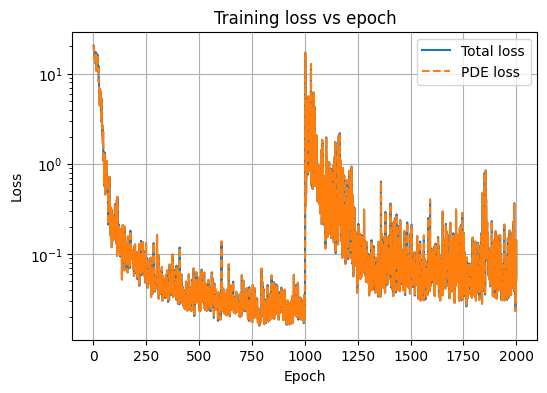

/tmp/ipython-input-697245022.py:20: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


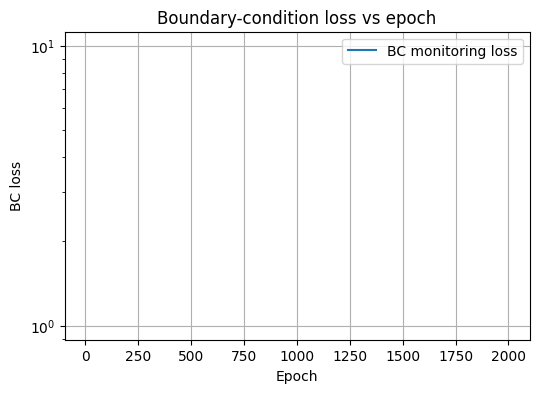

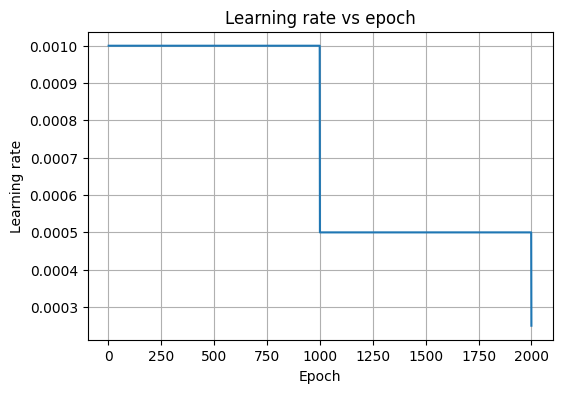

In [ ]:
# PLOT TRAINING CURVES

# 1) Total loss and PDE loss
plt.figure(figsize=(6, 4))
plt.plot(history["epoch"], history["total_loss"], label="Total loss")
plt.plot(history["epoch"], history["pde_loss"], label="PDE loss", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")   # log-scale helps see early behavior
plt.title("Training loss vs epoch")
plt.legend()
plt.grid(True)
plt.show()

# 2) Boundary monitoring loss (usually very small)
plt.figure(figsize=(6, 4))
plt.plot(history["epoch"], history["bc_loss"], label="BC monitoring loss")
plt.xlabel("Epoch")
plt.ylabel("BC loss")
plt.yscale("log")
plt.title("Boundary-condition loss vs epoch")
plt.legend()
plt.grid(True)
plt.show()

# 3) Learning rate schedule
plt.figure(figsize=(6, 4))
plt.plot(history["epoch"], history["lr"])
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate vs epoch")
plt.grid(True)
plt.show()


In [ ]:
# LOAD THE MODEL FROM DISK

# Make sure this matches the architecture used in training
loaded_model = KAPIRBF_PINN(M=128, hidden_meta=64).to(device)

state_dict = torch.load(MODEL_PATH, map_location=device)
loaded_model.load_state_dict(state_dict)
loaded_model.eval()

print("Loaded model from:", MODEL_PATH)


Loaded model from: meta_poisson_model.pt



=== Test case 1/4: center_in_range ===
  (x0, y0, nu) = (0.500, 0.500, 0.070)
  Relative L2 error = 2.008e-02

=== Test case 2/4: off_center_in_range ===
  (x0, y0, nu) = (0.450, 0.550, 0.090)
  Relative L2 error = 1.195e-02

=== Test case 3/4: shifted_out_of_range ===
  (x0, y0, nu) = (0.300, 0.300, 0.060)
  Relative L2 error = 3.569e-01

=== Test case 4/4: narrow_out_of_range ===
  (x0, y0, nu) = (0.500, 0.500, 0.030)
  Relative L2 error = 3.869e-02

Saved solution comparison figure to: figures/meta_poisson_results.png


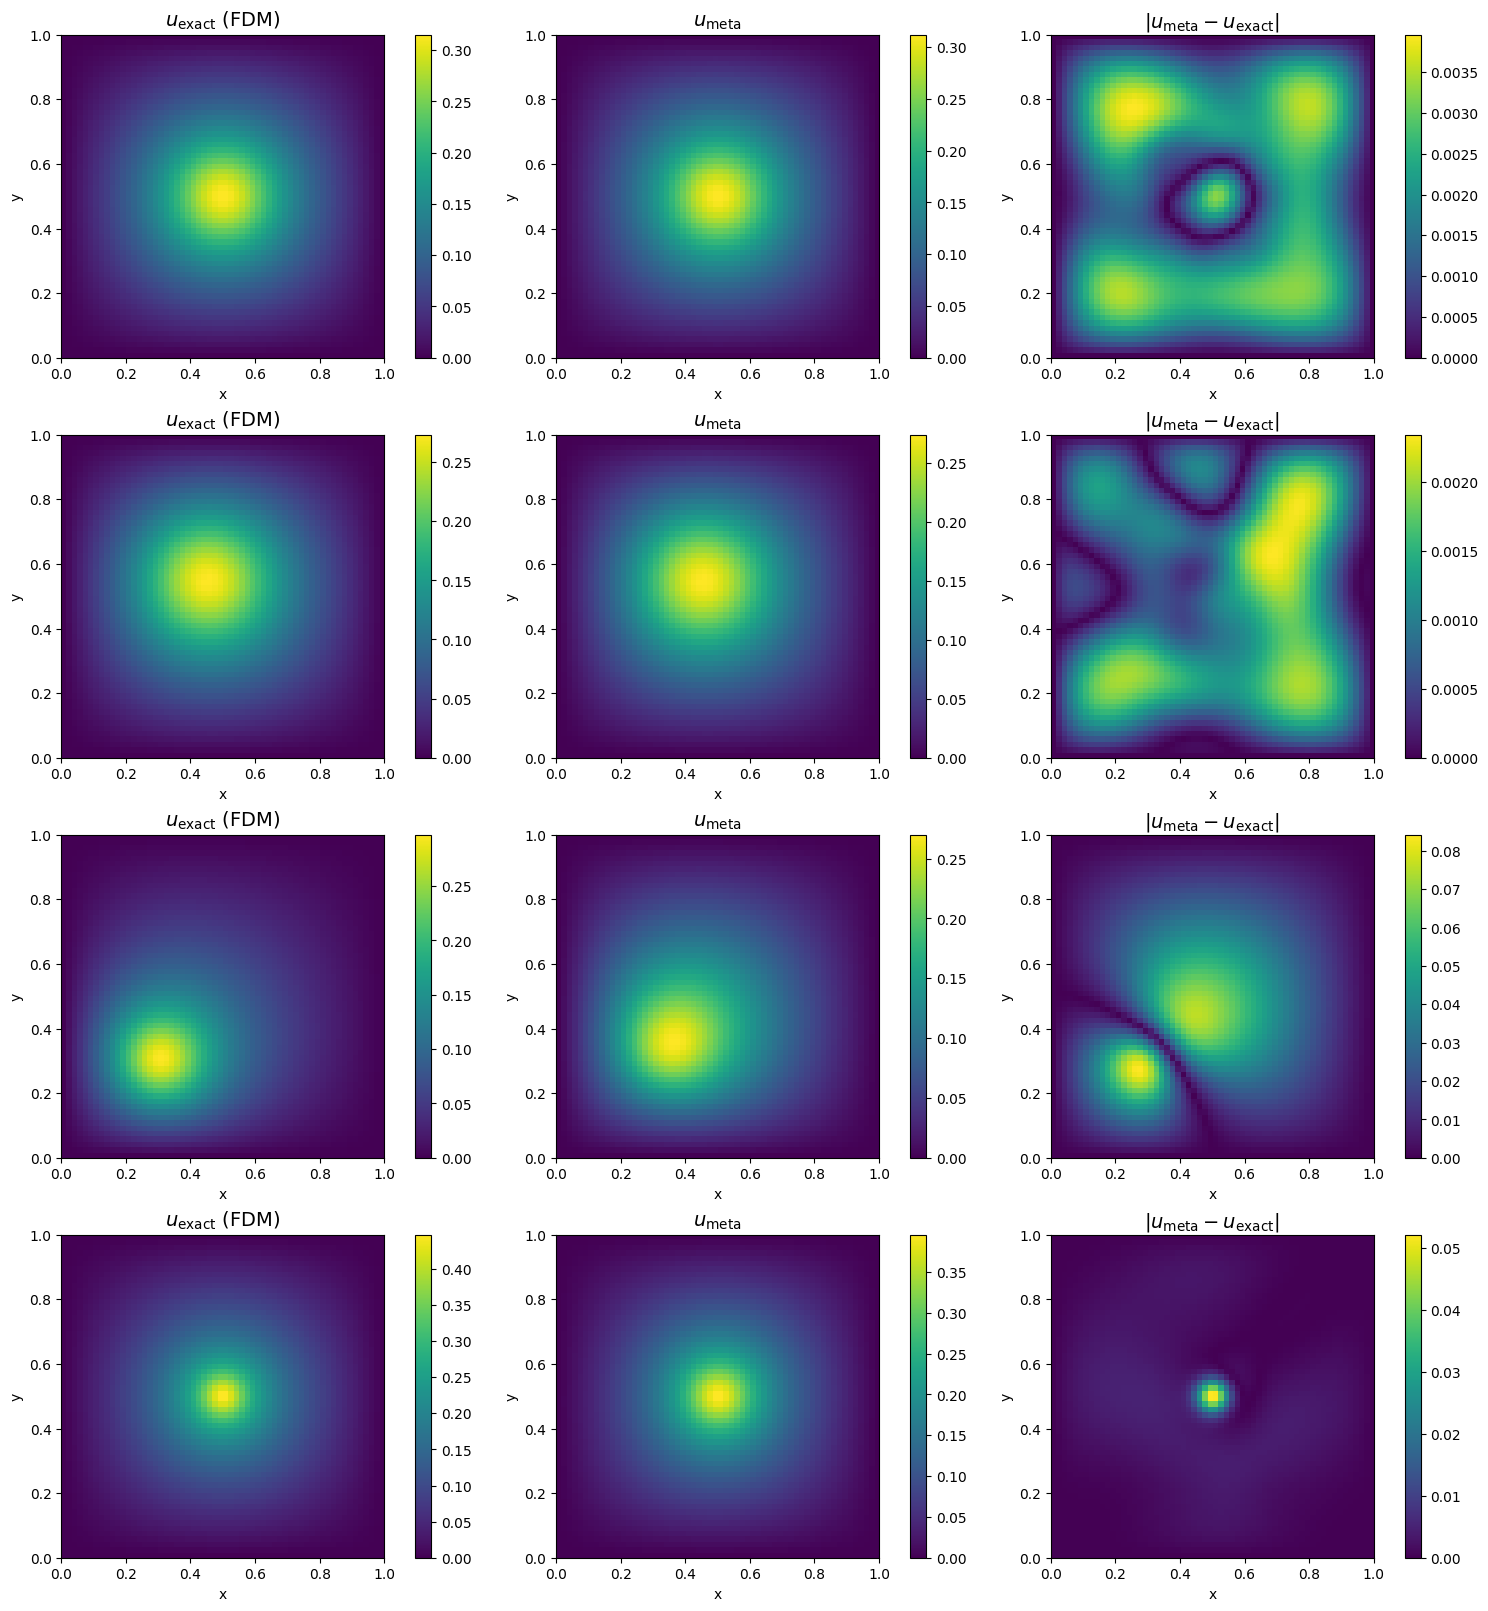


Summary of relative L2 errors:
  center_in_range          : 2.008e-02
  off_center_in_range      : 1.195e-02
  shifted_out_of_range     : 3.569e-01
  narrow_out_of_range      : 3.869e-02

Visualizing learned RBF centers for test cases...
Saved CLEANED RBF centers figure for center_in_range to: figures/rbf_centers_center_in_range.png


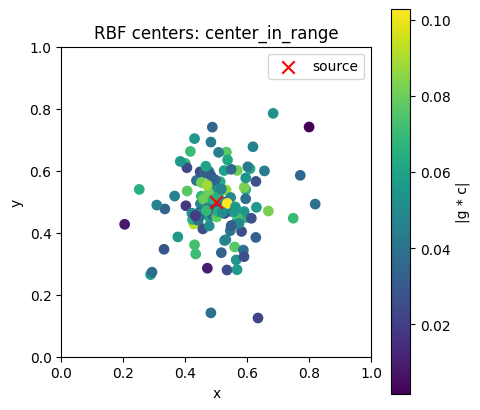

Saved CLEANED RBF centers figure for off_center_in_range to: figures/rbf_centers_off_center_in_range.png


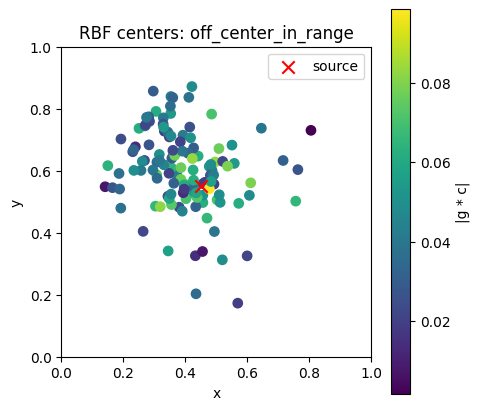

Saved CLEANED RBF centers figure for shifted_out_of_range to: figures/rbf_centers_shifted_out_of_range.png


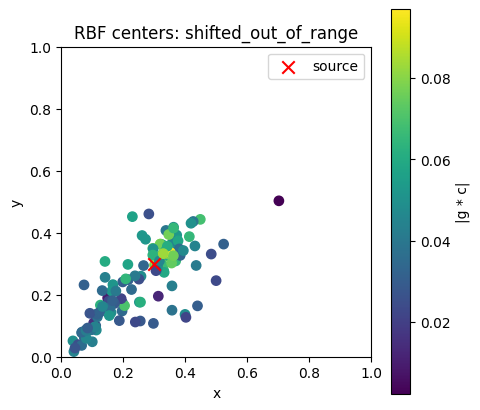

Saved CLEANED RBF centers figure for narrow_out_of_range to: figures/rbf_centers_narrow_out_of_range.png


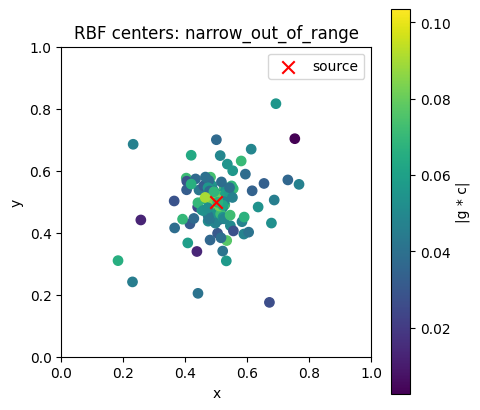

In [ ]:
# USE LOADED MODEL TO PRODUCE ALL PLOTS

evaluate_and_plot_solutions(loaded_model, N=60)
visualize_rbf_centers(loaded_model)


In [ ]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nContents of current directory:")
print(os.listdir("."))


Current working directory:
/content

Contents of current directory:
['.config', 'meta_poisson_model.pt', 'figures', 'sample_data']
